<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/alba_download_ReBeatICG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Code Part

## Download Dataset


In [1]:
!mkdir /content/RawData/
!wget -q https://zenodo.org/records/4725433/files/01_RawData.zip?download=1 -O /content/RawData/01_RawData.zip
!unzip -qo /content/RawData/01_RawData.zip -d /content/RawData/

!mkdir /content/FilteredData/
!wget -q https://zenodo.org/records/4725433/files/02_FilteredData.zip?download=1 -O /content/FilteredData/02_FilteredData.zip
!unzip -qo /content//FilteredData/02_FilteredData.zip -d /content//FilteredData/

!mkdir /content/Annotations/
!wget -q https://zenodo.org/records/4725433/files/03_ExpertAnnotations.zip?download=1 -O /content/Annotations/02_FilteredData.zip
!unzip -qo /content/Annotations/02_FilteredData.zip -d /content/Annotations/

In [2]:

import numpy as np
import pandas as pd
import scipy.io as sio

subject = input("Enter subject number: ")  # example: '24'
task = input("Enter task name: ")  # 'CW' or 'BL'

filename_raw = f'/content/RawData/RawData_Subject_{subject}_task_{task}.mat'
data_raw = sio.loadmat(filename_raw)

filename_filtered = f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat'
data_filtered = sio.loadmat(filename_filtered)

filename_annotation = f'/content/Annotations/Annotat_Subject_{subject}_task_{task}.mat'
annotation = sio.loadmat(filename_annotation)



Enter subject number: 24
Enter task name: CW


## Variable extraction
#### fs = 250 and 74469 samples -> 297.876 seconds = 4.9646 min




In [3]:
print(data_raw.keys())
print(data_filtered.keys())
print(annotation.keys())

# raw data variables
ecg_raw = data_raw['ECG']
icg_raw = data_raw['ICG']
fs_raw = data_raw['samplFreq']

# filtered data variables
ecg_filtered = data_filtered['ECG']
icg_filtered = data_filtered['ICG']
sgf = data_filtered['SGFiltLen']
fs_filtered = data_filtered['samplFreq']
print(sgf)

# annotation variables
annotations = annotation['annotPoints']
# print(fs_raw); print(fs_filtered) fs = 250
# print(len(ecg_raw)); print(len(ecg_filtered)) number of samples = 74469
print(annotations)

dict_keys(['__header__', '__version__', '__globals__', 'ECG', 'ICG', 'samplFreq'])
dict_keys(['__header__', '__version__', '__globals__', 'ECG', 'ICG', 'SGFiltLen', 'samplFreq'])
dict_keys(['__header__', '__version__', '__globals__', 'annotPoints'])
[[9]]
[[32778 32794 32837 32858]
 [32923 32936 32983 32997]
 [33068 33080 33124 33144]
 [33213 33226 33269 33288]
 [33358 33370 33411 33425]
 [33501 33514 33556 33575]
 [33641 33654 33698 33716]
 [33782 33794 33841 33856]
 [33923 33937 33981 34000]
 [34068 34080 34120 34139]
 [15295 15310 15350 15369]
 [15430 15443 15483 15495]
 [15564 15578 15619 15632]
 [15700 15713 15754 15767]
 [15836 15850 15888 15904]
 [15975 15989 16033 16055]
 [16116 16129 16170 16187]
 [16251 16264 16304 16324]
 [16386 16399 16435 16451]
 [16521 16533 16569 16586]
 [60848 60863 60904 60917]
 [60986 61001 61044 61060]
 [61128 61140 61189 61206]
 [61269 61282 61327 61347]
 [61414 61429 61469 61482]
 [61562 61573 61616 61633]
 [61703 61716 61758 61775]
 [61845 61857 6

## Raw data plots

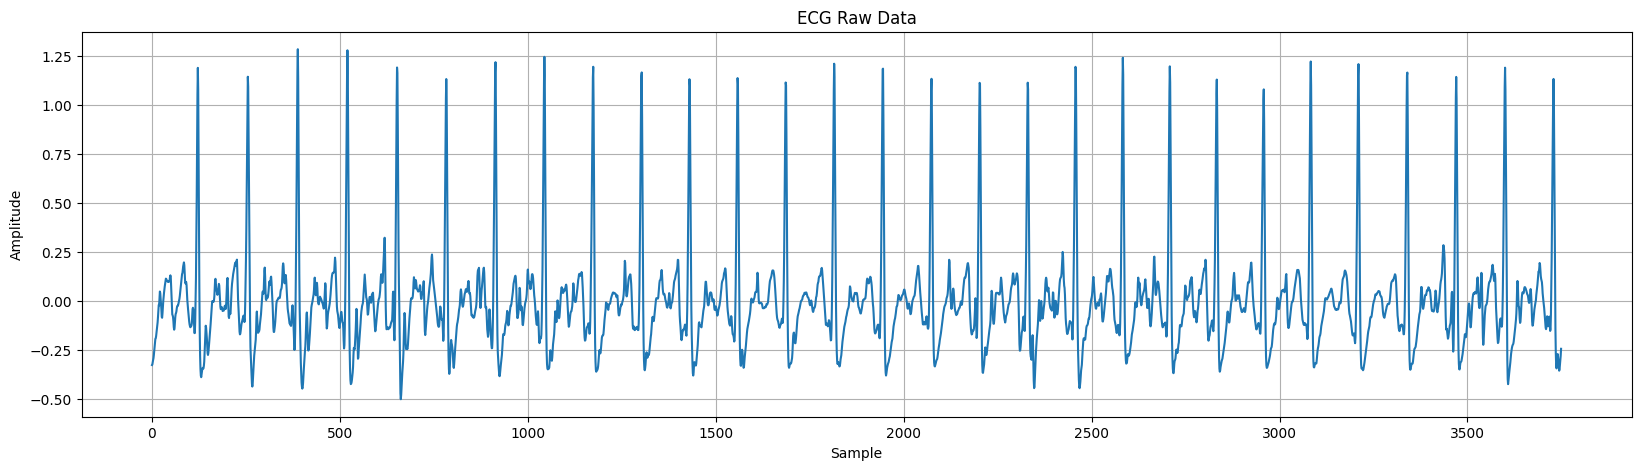

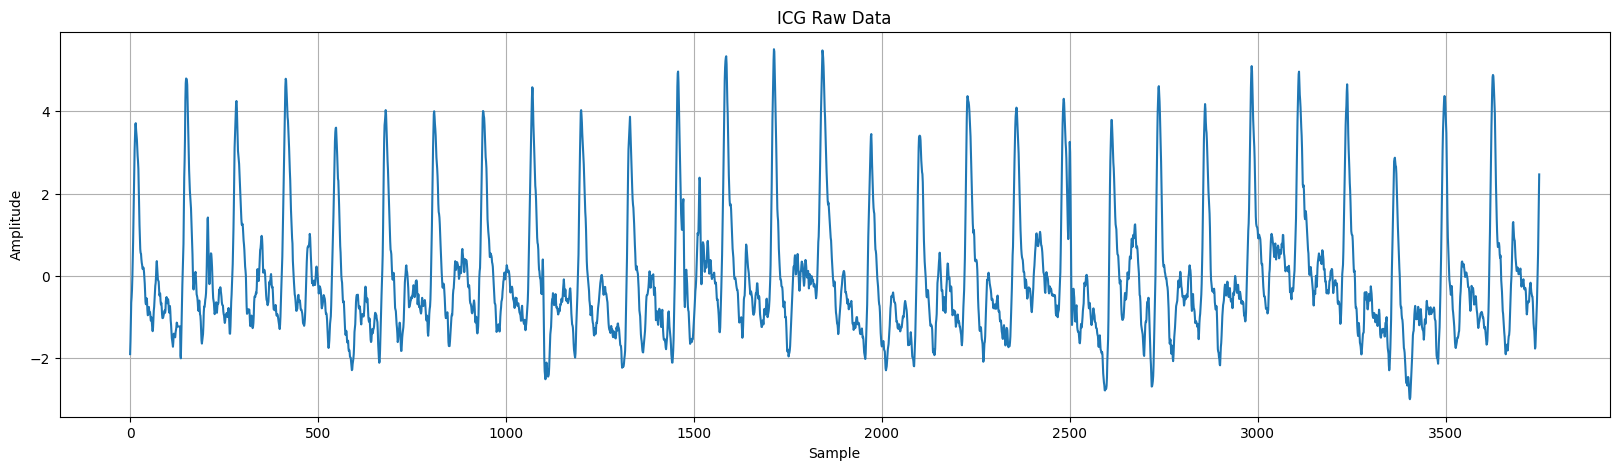

In [4]:
import matplotlib.pyplot as plt

# plot the ECG data
plt.figure(figsize=(20, 5))
plt.plot(ecg_raw[0:3750])
plt.title('ECG Raw Data')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# plot the ICG data
plt.figure(figsize=(20, 5))
plt.plot(icg_raw[0:3750])
plt.title('ICG Raw Data')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## Filtered data plots

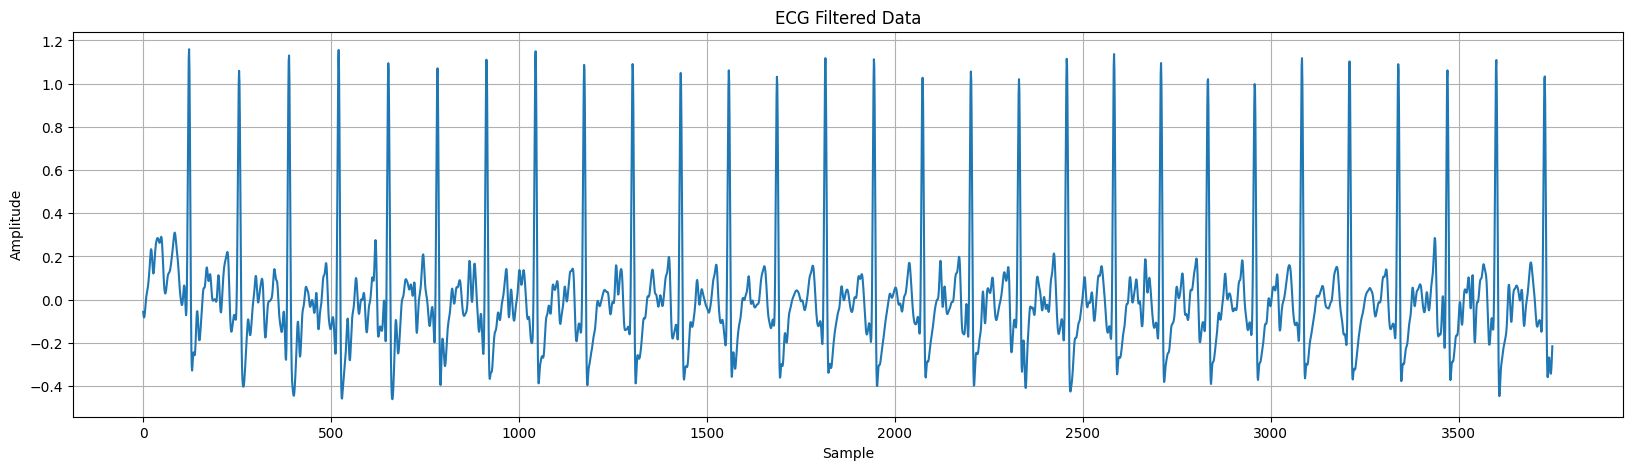

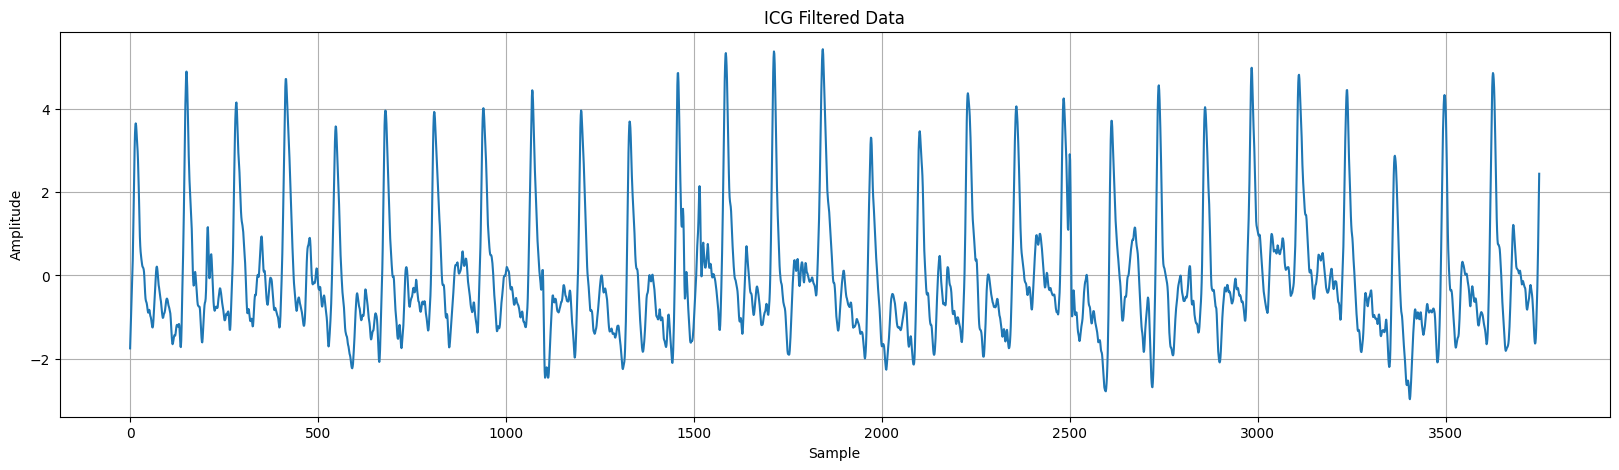

In [5]:
# plot the ECG data
plt.figure(figsize=(20, 5))
plt.plot(ecg_filtered[0:3750])
plt.title('ECG Filtered Data')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# plot the ICG data
plt.figure(figsize=(20, 5))
plt.plot(icg_filtered[0:3750])
plt.title('ICG Filtered Data')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## Annotations plot


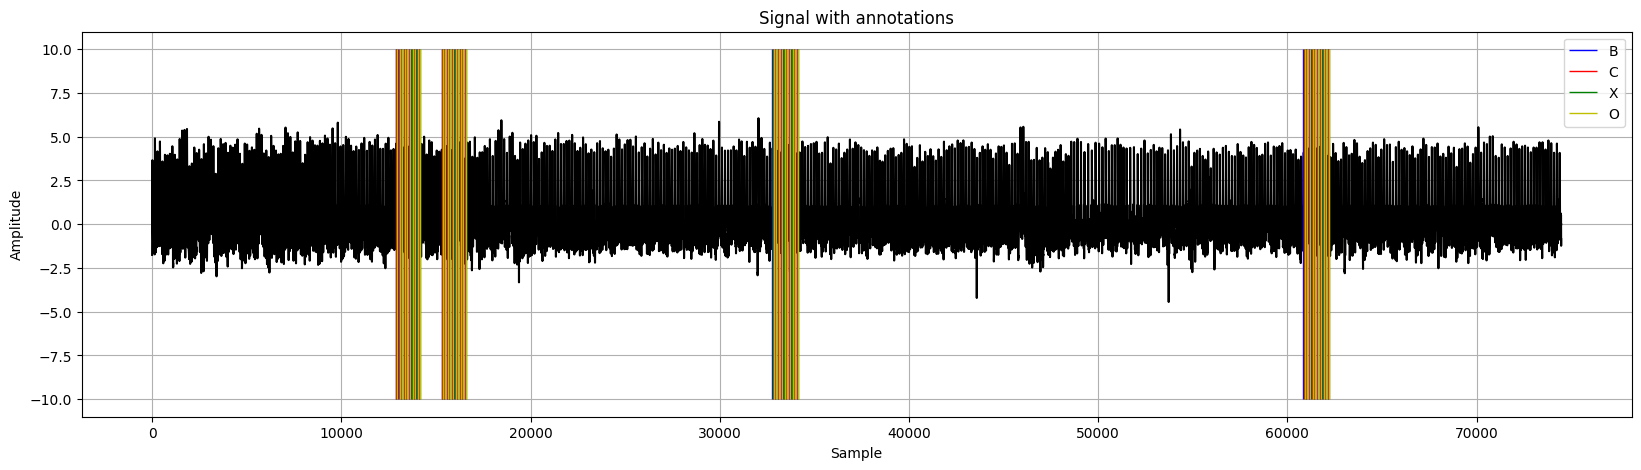

In [6]:
samples = np.arange(0, 74470, 1)

B = annotations[:, 0]
C = annotations[:, 1]
X = annotations[:, 2]
O = annotations[:, 3]

plt.figure(figsize=(20, 5))
plt.plot(ecg_filtered,'k')
plt.plot(icg_filtered,'k') # Overlay ICG signal
plt.vlines(B, ymin=-10, ymax=10, color='b', linewidth=1, label='B')
plt.vlines(C, ymin=-10, ymax=10, color='r', linewidth=1, label='C')
plt.vlines(X, ymin=-10, ymax=10, color='g', linewidth=1, label='X')
plt.vlines(O, ymin=-10, ymax=10, color='y', linewidth=1, label='O')

plt.title('Signal with annotations')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend() # Add legend
plt.grid(True)
plt.show()


### Events plot

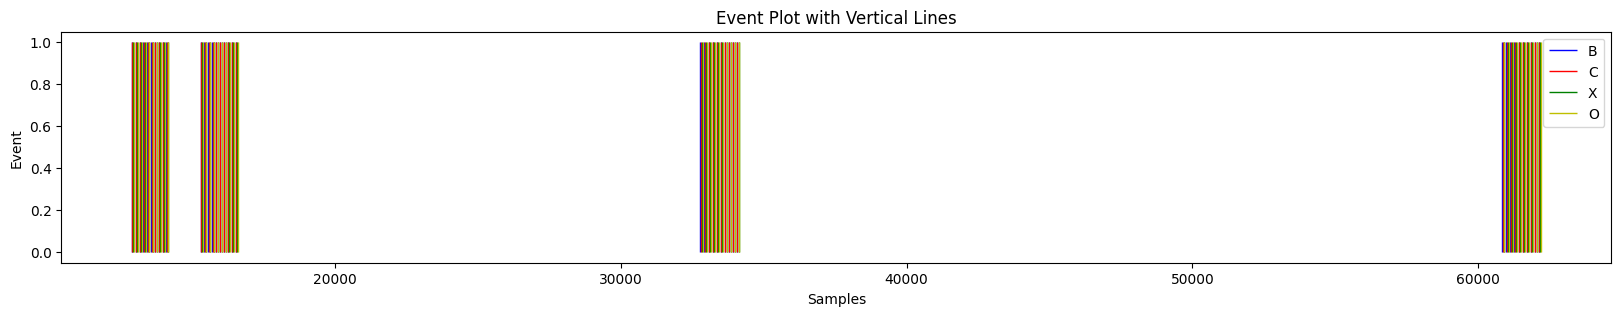

In [7]:

plt.figure(figsize=(20, 3))

plt.vlines(B, ymin=0, ymax=1, color='b', linewidth=1, label='B')
plt.vlines(C, ymin=0, ymax=1, color='r', linewidth=1, label='C')
plt.vlines(X, ymin=0, ymax=1, color='g', linewidth=1, label='X')
plt.vlines(O, ymin=0, ymax=1, color='y', linewidth=1, label='O')

plt.xlabel('Samples')
plt.ylabel('Event')
plt.title('Event Plot with Vertical Lines')
plt.legend()
plt.show()

### Event plot with slide


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

B = annotations[:, 0]
C = annotations[:, 1]
X = annotations[:, 2]
O = annotations[:, 3]

samples = np.arange(0, 74470, 1)  # From 0 to 74469 with step 1

# Update function
def update_plot(start_sample, end_sample):
    plt.figure(figsize=(20, 3))
    plt.plot(ecg_filtered,'b',linewidth = 1)
    plt.plot(icg_filtered,'k',linewidth = 1) # Overlay ICG signal
    # Compute the min and max amplitudes for the selected range of samples
    min_amplitude = min(np.min(ecg_filtered[start_sample:end_sample]), np.min(icg_filtered[start_sample:end_sample]))
    max_amplitude = max(np.max(ecg_filtered[start_sample:end_sample]), np.max(icg_filtered[start_sample:end_sample]))

    # Plot event markers with dynamic ymin and ymax based on the min and max amplitudes
    plt.vlines(B[(B >= start_sample) & (B <= end_sample)], ymin=min_amplitude, ymax=max_amplitude, color='r', linewidth=1, label='B')  # Vertical line for event B
    plt.vlines(C[(C >= start_sample) & (C <= end_sample)], ymin=min_amplitude, ymax=max_amplitude, color='y', linewidth=1, label='C')  # Vertical line for event C
    plt.vlines(X[(X >= start_sample) & (X <= end_sample)], ymin=min_amplitude, ymax=max_amplitude, color='g', linewidth=1, label='X')  # Vertical line for event X
    plt.vlines(O[(O >= start_sample) & (O <= end_sample)], ymin=min_amplitude, ymax=max_amplitude, color='m', linewidth=1, label='O')  # Vertical line for event O

    plt.xlabel('Samples')
    plt.ylabel('Event')
    plt.ylim([-3,3])
    plt.title('Event Plot with Vertical Lines')
    plt.legend()
    plt.xlim(start_sample, end_sample)  # Limit the sample range
    plt.show()

# Create interactive sliders
start_slider = widgets.IntSlider(min=0, max=len(samples) - 100, step=10, value=0, description="Start:")
end_slider = widgets.IntSlider(min=100, max=len(samples), step=10, value=len(samples), description="End:")

# Link sliders to the update function
interactive_plot = widgets.interactive(update_plot, start_sample=start_slider, end_sample=end_slider)

# Display the sliders and the interactive plot
display(interactive_plot, start_slider, end_slider)

interactive(children=(IntSlider(value=0, description='Start:', max=74370, step=10), IntSlider(value=74470, des…

IntSlider(value=0, description='Start:', max=74370, step=10)

IntSlider(value=74470, description='End:', max=74470, min=100, step=10)

# Pearson's test


In [13]:
# prompt: pearson's test to icg and ecg

from scipy.stats import pearsonr

correlation_coefficient, p_value = pearsonr(ecg_filtered, icg_filtered)
print(f"Pearson's correlation coefficient for ecg and icg filtered: {correlation_coefficient}")
print(f"P-value: {p_value}")

correlation_coefficient, p_value = pearsonr(ecg_raw, icg_raw)
print(f"Pearson's correlation coefficient for ecg and icg raw: {correlation_coefficient}")
print(f"P-value: {p_value}")

correlation_coefficient, p_value = pearsonr(ecg_raw, ecg_filtered)
print(f"Pearson's correlation coefficient for ecg raw and filtered: {correlation_coefficient}")
print(f"P-value: {p_value}")

correlation_coefficient, p_value = pearsonr(icg_filtered,icg_raw)
print(f"Pearson's correlation coefficient for icg raw and filtered: {correlation_coefficient}")
print(f"P-value: {p_value}")


Pearson's correlation coefficient for ecg and icg filtered: [-0.07077687]
P-value: [2.56089297e-83]
Pearson's correlation coefficient for ecg and icg raw: [-0.07520007]
P-value: [7.67879855e-94]
Pearson's correlation coefficient for ecg raw and filtered: [0.99696264]
P-value: [0.]
Pearson's correlation coefficient for icg raw and filtered: [0.99884498]
P-value: [0.]


1. **ecg_filtered and icg_filtered**
- r: -0.07077687
- P-value: 2.56089297*10^-83

Very weak negative linear relationship between the filtered ECG and filtered ICG signals. P-value extremely small, meaning the correlation is statistically significant
- the very weak correlation implies that the relationship is not practically meaningful.

2. **ecg_raw and icg_raw**
- r: -0.07520007
- P-value: 7.67879855 \times 10^{-94}

same analysis as before

3. **ecg_raw and ecg_filtered**
- r: 0.99696264
- P-value: 0

Almost perfect positive linear relationship between the raw and filtered ECG signals. This result is expected, as filtering generally preserves the structure of the signal.

4. **icg_raw and icg_filtered**
- r: 0.99884498
- P-value: 0

same analysis as before

Why is it not correlated when they should since they both provide information about the heart activity?

Hypothesis:
- the signals are not aligned: they seem aligned because the R peaks are right before the E peaks of ICG
- the signals are not from the same time

Typical ECG amplitude: 0.5 mV to 5 mV
Typical ICG amplitude: 0.5 Ω to 5 Ω
